In [1]:
import torch
import numpy as np
torch.__version__

'2.11.0'

In [2]:
from sklearn import datasets
iris = datasets.load_iris()
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [3]:
iris['data'].shape, iris['data'].dtype

((150, 4), dtype('float64'))

In [4]:
iris['data'][:15]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2]])

In [5]:
iris['feature_names']

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [6]:
np.unique(iris['target'])

array([0, 1, 2])

In [7]:
iris['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

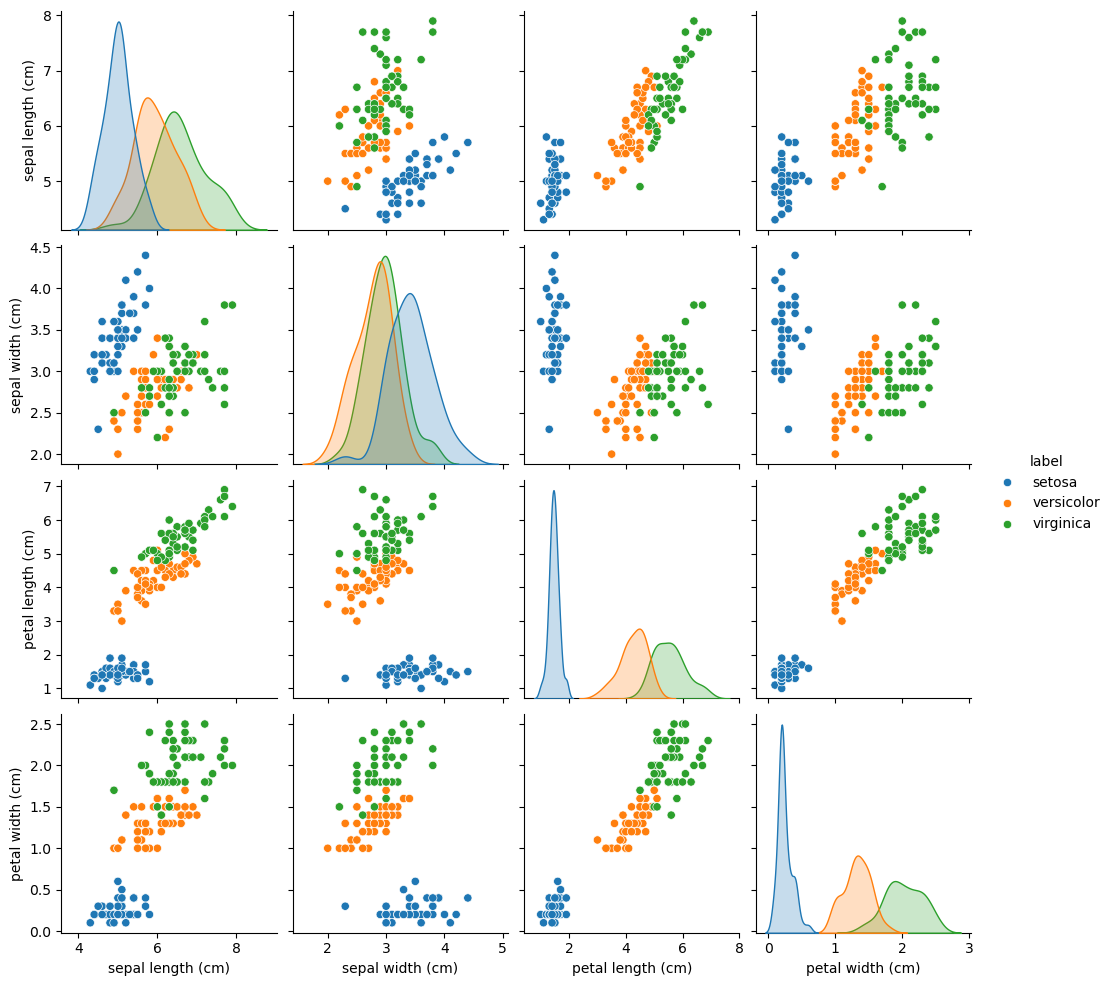

In [8]:
%matplotlib inline
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

features_df = pd.DataFrame(
    iris['data'],
    columns=iris['feature_names']
)
features_df['label'] = iris['target_names'][iris['target']]
sns.pairplot(features_df, hue='label')
plt.show()

In [9]:
preprocessed_features = (iris['data'] - iris['data'].mean(axis=0)) / iris['data'].std(axis=0)

iris['target']

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

**Assessed Question: Why do we want to do this?**

To prevent overfitting. We need new data to test on to ensure it's trained on the flowers in general rather than just the data in this set.

**Assessed Question: Why do we need to shuffle before splitting it? Hint: take a look at the entire dataset array.**

Because the data is ordered so the training set would be completely unrealted to the testing set.

In [10]:
from sklearn.model_selection import train_test_split

labels = iris['target']
train_features, test_features, train_labels, test_labels = train_test_split(preprocessed_features, labels, test_size=1/3)

In [11]:
features = {
    'train': torch.tensor(train_features, dtype=torch.float32),
    'test': torch.tensor(test_features, dtype=torch.float32),
}
labels = {
    'train': torch.tensor(train_labels, dtype=torch.long),
    'test': torch.tensor(test_labels, dtype=torch.long),}

In [12]:
from torch import nn
from torch.nn import functional as F
from typing import Callable

class MLP(nn.Module):
    def __init__(self,
                 input_size: int,
                 hidden_layer_size: int,
                 output_size: int,
                 activation_fn: Callable[[torch.Tensor], torch.Tensor] = F.relu):
        super().__init__()
        self.l1 = nn.Linear(input_size, hidden_layer_size)
        self.l2 = nn.Linear(hidden_layer_size, output_size)
        self.activation_fn = activation_fn

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        x = self.l1(inputs)
        x = self.activation_fn(x)
        x = self.l2(x)
        return x

In [13]:
feature_count = 4
hidden_layer_size = 100
class_count = 3
model = MLP(feature_count, hidden_layer_size, class_count)

In [14]:
logits = model.forward(features['train'])
logits.shape

torch.Size([100, 3])

In [15]:
loss_function = nn.CrossEntropyLoss()

loss = loss_function(logits, labels['train'])
loss.backward()

/opt/anaconda/2026/lib/python3.13/site-packages/torch/autograd/graph.py:869: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /home/task_177987125279953/croot/libtorch_1779871314136/work/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


In [16]:
def accuracy(probs: torch.FloatTensor, targets: torch.LongTensor) -> float:
    maximums = torch.argmax(probs, dim=1)
    compare = torch.eq(maximums, targets)
    sum = torch.sum(compare)
    return sum.item()/len(compare)

In [17]:
def check_accuracy(probs: torch.FloatTensor,
                   labels: torch.LongTensor,
                   expected_accuracy: float):
    actual_accuracy = float(accuracy(probs, labels))
    assert actual_accuracy == expected_accuracy, f"Expected accuracy to be {expected_accuracy} but was {actual_accuracy}"

check_accuracy(torch.tensor([[0, 1],
                             [0, 1],
                             [0, 1],
                             [0, 1],
                             [0, 1]]),
               torch.ones(5, dtype=torch.long),
               1.0)
check_accuracy(torch.tensor([[1, 0],
                             [0, 1],
                             [0, 1],
                             [0, 1],
                             [0, 1]]),
               torch.ones(5, dtype=torch.long),
               0.8)
check_accuracy(torch.tensor([[1, 0],
                             [1, 0],
                             [0, 1],
                             [0, 1],
                             [0, 1]]),
               torch.ones(5, dtype=torch.long),
               0.6)
check_accuracy(torch.tensor([[1, 0],
                             [1, 0],
                             [1, 0],
                             [1, 0],
                             [1, 0]]),
               torch.ones(5, dtype=torch.long),
               0.0)
print("All test cases passed")

All test cases passed


In [28]:
from torch import optim


# Define the model to optimze
model = MLP(feature_count, hidden_layer_size, class_count)

# The optimizer we'll use to update the model parameters
optimizer = optim.SGD(model.parameters(), lr=0.05)

# Now we define the loss function.
criterion = nn.CrossEntropyLoss() 

# Now we iterate over the dataset a number of times. Each iteration of the entire dataset 
# is called an epoch.
loss_vals_before = []
for epoch in range(0, 100):
    # We compute the forward pass of the network
    logits = model.forward(features['train'])
    # Then the value of loss function 
    loss = criterion(logits,  labels['train'])
    
    # How well the network does on the batch is an indication of how well training is 
    # progressing
    print("epoch: {} train accuracy: {:2.2f}, loss: {:5.5f}".format(
        epoch,
        accuracy(logits, labels['train']) * 100,
        loss.item()
    ))
    loss_vals_before.append(loss.item())
    
    # Now we compute the backward pass, which populates the `.grad` attributes of the parameters
    loss.backward()
    # Now we update the model parameters using those gradients
    optimizer.step()
    # Now we need to zero out the `.grad` buffers as otherwise on the next backward pass we'll add the 
    # new gradients to the old ones.
    optimizer.zero_grad()
    
# Finally we can test our model on the test set and get an unbiased estimate of its performance.    
logits = model.forward(features['test'])    
test_accuracy = accuracy(logits, labels['test']) * 100
print("test accuracy: {:2.2f}".format(test_accuracy))

epoch: 0 train accuracy: 43.00, loss: 1.10527
epoch: 1 train accuracy: 59.00, loss: 0.99812
epoch: 2 train accuracy: 73.00, loss: 0.91101
epoch: 3 train accuracy: 79.00, loss: 0.84029
epoch: 4 train accuracy: 79.00, loss: 0.78259
epoch: 5 train accuracy: 80.00, loss: 0.73501
epoch: 6 train accuracy: 83.00, loss: 0.69528
epoch: 7 train accuracy: 83.00, loss: 0.66163
epoch: 8 train accuracy: 83.00, loss: 0.63275
epoch: 9 train accuracy: 86.00, loss: 0.60769
epoch: 10 train accuracy: 86.00, loss: 0.58570
epoch: 11 train accuracy: 86.00, loss: 0.56622
epoch: 12 train accuracy: 86.00, loss: 0.54882
epoch: 13 train accuracy: 87.00, loss: 0.53317
epoch: 14 train accuracy: 87.00, loss: 0.51900
epoch: 15 train accuracy: 87.00, loss: 0.50611
epoch: 16 train accuracy: 86.00, loss: 0.49432
epoch: 17 train accuracy: 87.00, loss: 0.48348
epoch: 18 train accuracy: 87.00, loss: 0.47348
epoch: 19 train accuracy: 87.00, loss: 0.46422
epoch: 20 train accuracy: 88.00, loss: 0.45561
epoch: 21 train accurac

epoch: 0 train accuracy: 62.00, loss: 1.00557
epoch: 1 train accuracy: 85.00, loss: 0.91001
epoch: 2 train accuracy: 90.00, loss: 0.76606
epoch: 3 train accuracy: 87.00, loss: 0.63030
epoch: 4 train accuracy: 86.00, loss: 0.53204
epoch: 5 train accuracy: 86.00, loss: 0.46635
epoch: 6 train accuracy: 86.00, loss: 0.41821
epoch: 7 train accuracy: 86.00, loss: 0.37796
epoch: 8 train accuracy: 88.00, loss: 0.34235
epoch: 9 train accuracy: 89.00, loss: 0.31152
epoch: 10 train accuracy: 90.00, loss: 0.28649
epoch: 11 train accuracy: 89.00, loss: 0.26771
epoch: 12 train accuracy: 88.00, loss: 0.25459
epoch: 13 train accuracy: 87.00, loss: 0.24556
epoch: 14 train accuracy: 87.00, loss: 0.23855
epoch: 15 train accuracy: 88.00, loss: 0.23169
epoch: 16 train accuracy: 89.00, loss: 0.22378
epoch: 17 train accuracy: 89.00, loss: 0.21453
epoch: 18 train accuracy: 91.00, loss: 0.20438
epoch: 19 train accuracy: 91.00, loss: 0.19412
epoch: 20 train accuracy: 92.00, loss: 0.18451
epoch: 21 train accurac

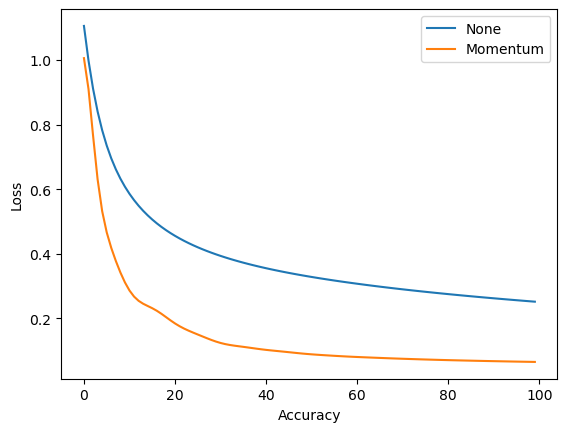

In [31]:
from torch import optim
import matplotlib.pyplot as plt


def train_n_test(lr=0.05, print_loss=True, momentum=0, weight_decay=0):
    # Define the model to optimze
    model = MLP(feature_count, hidden_layer_size, class_count)

    # The optimizer we'll use to update the model parameters
    optimizer = optim.SGD(model.parameters(), lr=0.05, momentum=momentum, weight_decay=weight_decay)

    # Now we define the loss function.
    criterion = nn.CrossEntropyLoss() 

    # Now we iterate over the dataset a number of times. Each iteration of the entire dataset 
    # is called an epoch.
    loss_values = []
    for epoch in range(0, 100):
        # We compute the forward pass of the network
        logits = model.forward(features['train'])
        # Then the value of loss function 
        loss = criterion(logits,  labels['train'])
    
        # How well the network does on the batch is an indication of how well training is 
        # progressing
        if print_loss:
            print("epoch: {} train accuracy: {:2.2f}, loss: {:5.5f}".format(
                epoch,
                accuracy(logits, labels['train']) * 100,
                loss.item()
            ))
        loss_values.append(loss.item())
    
        # Now we compute the backward pass, which populates the `.grad` attributes of the parameters
        loss.backward()
        # Now we update the model parameters using those gradients
        optimizer.step()
        # Now we need to zero out the `.grad` buffers as otherwise on the next backward pass we'll add the 
        # new gradients to the old ones.
        optimizer.zero_grad()
    
    # Finally we can test our model on the test set and get an unbiased estimate of its performance.    
    logits = model.forward(features['test'])    
    test_accuracy = accuracy(logits, labels['test']) * 100
    print("test accuracy: {:2.2f}".format(test_accuracy))
    
    return loss_values

loss_values = train_n_test(lr=0.05, momentum=0.9)

plt.plot([i for i in range(len(loss_vals_before))], loss_vals_before, label="None")
plt.plot([i for i in range(len(loss_values))], loss_values, label="Momentum")
plt.xlabel("Accuracy")
plt.ylabel("Loss")
plt.legend()
plt.show()

**Assessed Question: . What do you notice about the affect this has on the training loss and train accuracy?**

The accuracy has a small improvement and the loss a great improvement so the model is making much smaller errors and making errors a bit less often.

**What do you think is the best way to investigate overfitting in models?**

By testing it with new data.

test accuracy: 98.00
test accuracy: 98.00
test accuracy: 98.00
test accuracy: 98.00
test accuracy: 96.00
test accuracy: 96.00
test accuracy: 94.00
test accuracy: 92.00
test accuracy: 92.00
test accuracy: 92.00


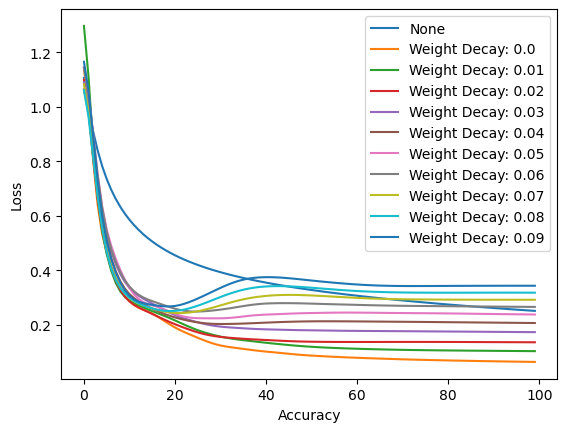

In [56]:
from torch import optim
import matplotlib.pyplot as plt


def train_n_test(lr=0.05, print_loss=True, momentum=0, weight_decay=0):
    # Define the model to optimze
    model = MLP(feature_count, hidden_layer_size, class_count)

    # The optimizer we'll use to update the model parameters
    optimizer = optim.SGD(model.parameters(), lr=0.05, momentum=momentum, weight_decay=weight_decay)

    # Now we define the loss function.
    criterion = nn.CrossEntropyLoss() 

    # Now we iterate over the dataset a number of times. Each iteration of the entire dataset 
    # is called an epoch.
    loss_values = []
    for epoch in range(0, 100):
        # We compute the forward pass of the network
        logits = model.forward(features['train'])
        # Then the value of loss function 
        loss = criterion(logits,  labels['train'])
    
        # How well the network does on the batch is an indication of how well training is 
        # progressing
        if print_loss:
            print("epoch: {} train accuracy: {:2.2f}, loss: {:5.5f}".format(
                epoch,
                accuracy(logits, labels['train']) * 100,
                loss.item()
            ))
        loss_values.append(loss.item())
    
        # Now we compute the backward pass, which populates the `.grad` attributes of the parameters
        loss.backward()
        # Now we update the model parameters using those gradients
        optimizer.step()
        # Now we need to zero out the `.grad` buffers as otherwise on the next backward pass we'll add the 
        # new gradients to the old ones.
        optimizer.zero_grad()
    
    # Finally we can test our model on the test set and get an unbiased estimate of its performance.    
    logits = model.forward(features['test'])    
    test_accuracy = accuracy(logits, labels['test']) * 100
    print("test accuracy: {:2.2f}".format(test_accuracy))
    
    return loss_values


plt.plot([i for i in range(len(loss_vals_before))], loss_vals_before, label="None")

for x in range(0,10,1):
    weight_decay = x / 100tra Recap Recording
    loss_values = train_n_test(print_loss=False, lr=0.1, momentum=0.9, weight_decay=(weight_decay))
    plt.plot([i for i in range(len(loss_values))], loss_values, label="Weight Decay: "+ str(weight_decay))


plt.xlabel("Accuracy")
plt.ylabel("Loss")
plt.legend()
plt.show()

**Assessed Question: At what value does weight decay start to degrade performance?**
Anything above zero

test accuracy: 98.00
test accuracy: 100.00
test accuracy: 96.00


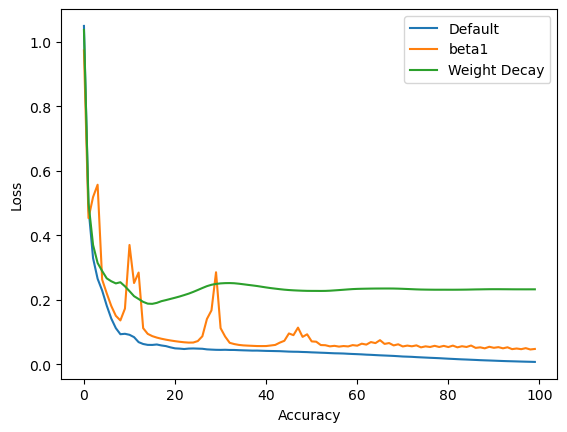

In [64]:
from torch.utils.tensorboard import SummaryWriter

def train_n_test(lr=0.05, print_loss=True, betas=(0.9, 0.999), eps=1e-8, weight_decay=0):
    summary_writer = SummaryWriter('logs', flush_secs=5)
    # Define the model to optimze
    model = MLP(feature_count, hidden_layer_size, class_count)

    # The optimizer we'll use to update the model parameters
    optimizer = optim.Adam(model.parameters(), lr=0.05, betas=betas, eps=eps, weight_decay=weight_decay)

    # Now we define the loss function.
    criterion = nn.CrossEntropyLoss() 

    # Now we iterate over the dataset a number of times. Each iteration of the entire dataset 
    # is called an epoch.
    loss_values = []
    for epoch in range(0, 100):
        # We compute the forward pass of the network
        logits = model.forward(features['train'])
        # Then the value of loss function 
        loss = criterion(logits,  labels['train'])
    
        # How well the network does on the batch is an indication of how well training is 
        # progressing
        if print_loss:
            print("epoch: {} train accuracy: {:2.2f}, loss: {:5.5f}".format(
                epoch,
                accuracy(logits, labels['train']) * 100,
                loss.item()
            ))
        loss_values.append(loss.item())
    
        # Now we compute the backward pass, which populates the `.grad` attributes of the parameters
        loss.backward()
        # Now we update the model parameters using those gradients
        optimizer.step()
        # Now we need to zero out the `.grad` buffers as otherwise on the next backward pass we'll add the 
        # new gradients to the old ones.
        optimizer.zero_grad()

        # tensorboard stuff
        train_accuracy = accuracy(logits, labels['train']) * 100
        summary_writer.add_scalar('accuracy/train', train_accuracy, epoch)
        summary_writer.add_scalar('loss/train', loss.item(), epoch)
    summary_writer.close()
    # Finally we can test our model on the test set and get an unbiased estimate of its performance.    
    logits = model.forward(features['test'])    
    test_accuracy = accuracy(logits, labels['test']) * 100
    print("test accuracy: {:2.2f}".format(test_accuracy))
    
    return loss_values


loss_values = train_n_test(lr=0.05, print_loss=False, betas=(0.9, 0.999), eps=1e-8, weight_decay=0)
plt.plot([i for i in range(len(loss_values))], loss_values, label="Default")

loss_values = train_n_test(lr=0.05, print_loss=False, betas=(0.1, 0.999), eps=1e-8, weight_decay=0)
plt.plot([i for i in range(len(loss_values))], loss_values, label="beta1")

loss_values = train_n_test(lr=0.05, print_loss=False, betas=(0.9, 0.999), eps=1e-8, weight_decay=0.05)
plt.plot([i for i in range(len(loss_values))], loss_values, label="Weight Decay")

plt.xlabel("Accuracy")
plt.ylabel("Loss")
plt.legend()
plt.show()



**Assessed Question: What is the effect of increasing beta1?**

The loss is more volatile at each fifth of accuracy??

I0000 00:00:1791300014.126723   16041 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791300014.199967   16041 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
